# 1. Imports & global config

In [3]:
# System utilities
import os
import re
from collections import Counter
from pathlib import Path

# Data & numerical
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

# Visualization
from wordcloud import WordCloud

# ML utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Notebook display
from IPython.display import display

print("TensorFlow:", tf.__version__)
nltk.download("stopwords")


TensorFlow: 2.18.1


[nltk_data] Downloading package stopwords to /home/rabby/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# 3. Data Loading 

In [6]:
DATA_PATH = "data/training.1600000.processed.noemoticon.csv"

df = pd.read_csv(
    DATA_PATH,
    header=None,
    engine="python",
    encoding="latin-1",
    encoding_errors="ignore"
)

df.columns = ["sentiment", "id", "date", "query", "user_id", "text"]
df = df[["sentiment", "text"]]

display(df.head())

,sentiment,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


# 4. EDA

## Sentiment Distribution

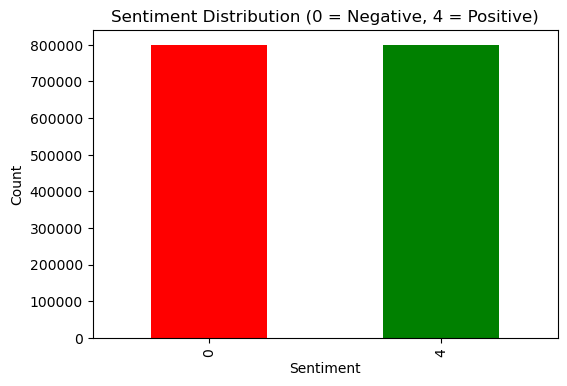

In [10]:
plt.figure(figsize=(6,4))
df['sentiment'].value_counts().plot(kind='bar', color=['red','green'])
plt.title("Sentiment Distribution (0 = Negative, 4 = Positive)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

## Tweet Length Distribution

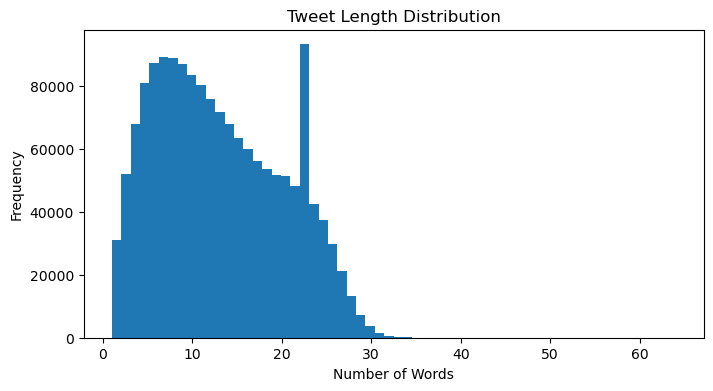

In [13]:
df["text_len"] = df["text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,4))
plt.hist(df["text_len"], bins=60)
plt.title("Tweet Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

## WordClouds

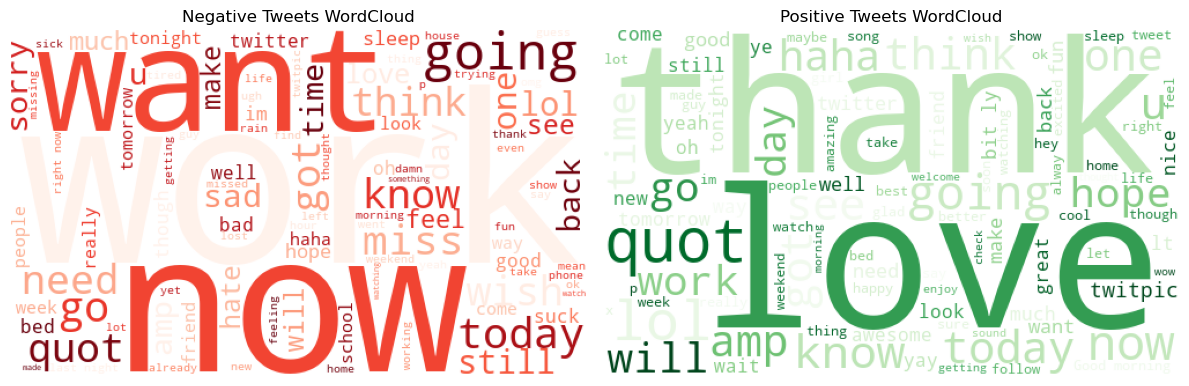

In [16]:
neg_text = " ".join(df[df["sentiment"]==0]["text"])
pos_text = " ".join(df[df["sentiment"]==4]["text"])

plt.figure(figsize=(12,5))

# Negative tweets wordcloud (red colors)
plt.subplot(1,2,1)
neg_wordcloud = WordCloud(width=500, height=300, 
                         background_color='white',
                         colormap='Reds',
                         max_words=100).generate(neg_text)
plt.imshow(neg_wordcloud)
plt.title("Negative Tweets WordCloud")
plt.axis("off")

# Positive tweets wordcloud (green colors)
plt.subplot(1,2,2)
pos_wordcloud = WordCloud(width=500, height=300, 
                         background_color='white',
                         colormap='Greens',
                         max_words=100).generate(pos_text)
plt.imshow(pos_wordcloud)
plt.title("Positive Tweets WordCloud")
plt.axis("off")

plt.tight_layout()
plt.show()

# 5. Text Preprocessing

In [19]:
stop_words = stopwords.words("english")
stemmer = SnowballStemmer("english")

clean_re = r'@\S+|https?:\S+|http?:\S|[^A-Za-z0-9]+'

def preprocess(text, stem=False):
    text = re.sub(clean_re, " ", str(text).lower()).strip()
    tokens = []
    for token in text.split():
        if token not in stop_words:
            tokens.append(stemmer.stem(token) if stem else token)
    return " ".join(tokens)

# 6. Apply Cleaning

In [22]:
df["clean_text"] = df["text"].apply(preprocess)
display(df[["text", "clean_text"]].head())

,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww bummer shoulda got david carr third day
1,is upset that he can't update his Facebook by ...,upset update facebook texting might cry result...
2,@Kenichan I dived many times for the ball. Man...,dived many times ball managed save 50 rest go ...
3,my whole body feels itchy and like its on fire,whole body feels itchy like fire
4,"@nationwideclass no, it's not behaving at all....",behaving mad see


# Tokenizer Hyperparameters

In [25]:
# Tokenizer Hyperparameters
MAX_WORDS = 100000
MAX_SEQ_LENGTH = 30

# 7. Train/Test Split

In [28]:
# Split train and test sets

train_df, test_df = train_test_split(df, test_size=0.2, random_state=666, shuffle=True)

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (1280000, 4)
Test size: (320000, 4)


# 8. Tokenizer + Padding

In [31]:
tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(train_df["clean_text"])

x_train = pad_sequences(
    tokenizer.texts_to_sequences(train_df["clean_text"]),
    maxlen=MAX_SEQ_LENGTH
)

x_test = pad_sequences(
    tokenizer.texts_to_sequences(test_df["clean_text"]),
    maxlen=MAX_SEQ_LENGTH
)

y_train = (train_df["sentiment"]==4).astype(int).values
y_test  = (test_df["sentiment"]==4).astype(int).values

# 9. Load GloVe Embeddings

In [34]:
GLOVE_PATH = "data/glove.6B.300d.txt"

# Model Hyperparameters
EMBEDDING_DIM = 300
BATCH_SIZE = 10000
EPOCHS = 10
LR = 1e-3
MODEL_PATH = "./best_model.hdf5"

In [36]:
embedding_index = {}
with open(GLOVE_PATH, encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = vector

print("Loaded word vectors:", len(embedding_index))

Loaded word vectors: 400000


# 10 Build Embedding Matrix

In [42]:
vocab_size = len(tokenizer.word_index) + 1

embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

for word, idx in tokenizer.word_index.items():
    vec = embedding_index.get(word)
    if vec is not None and idx < vocab_size:
        embedding_matrix[idx] = vec

embedding_matrix.shape

(290683, 300)

# 11. Build RNN Model

In [44]:
model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_shape=(MAX_SEQ_LENGTH,),
        trainable=False
    ),

    SimpleRNN(128),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    metrics=["accuracy"]
)

model.summary()

/home/rabby/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 300)        │    87,204,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        54,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,259,941 (332.87 MB)

 Trainable params: 55,041 (215.00 KB)

 Non-trainable params: 87,204,900 (332.66 MB)

# 12. Train Model

In [49]:
history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2
)

Epoch 1/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 65s 624ms/step - accuracy: 0.6868 - loss: 0.5875 - val_accuracy: 0.7186 - val_loss: 0.5495
Epoch 2/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 62s 603ms/step - accuracy: 0.7149 - loss: 0.5540 - val_accuracy: 0.7251 - val_loss: 0.5403
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 66s 637ms/step - accuracy: 0.7228 - loss: 0.5432 - val_accuracy: 0.7319 - val_loss: 0.5320
Epoch 4/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 66s 639ms/step - accuracy: 0.7322 - loss: 0.5313 - val_accuracy: 0.7403 - val_loss: 0.5204
Epoch 5/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 64s 628ms/step - accuracy: 0.7402 - loss: 0.5209 - val_accuracy: 0.7451 - val_loss: 0.5135
Epoch 6/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 67s 650ms/step - accuracy: 0.7447 - loss: 0.5142 - val_accuracy: 0.7501 - val_loss: 0.5078
Epoch 7/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 67s 651ms/step - accuracy: 0.7414 - loss: 0.5192 - val_accuracy: 0.7505 - val_loss: 0.5069
Epoch 8/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 68s 663ms/step - accuracy: 0.7503 - loss: 0

# 13. Visualization

## 13.1 Training & Validation Loss Curve

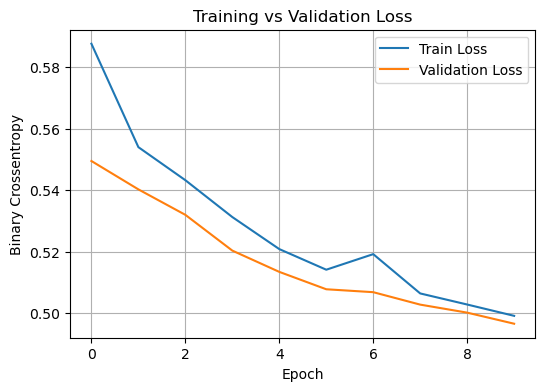

In [53]:
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## 13.2 Training & Validation Accuracy Curve

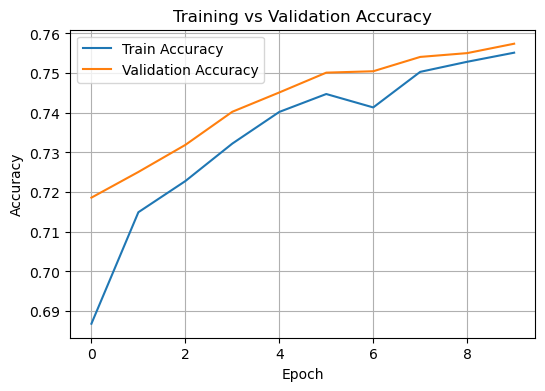

In [56]:
plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 13.3 Evaluate on Test Set

In [59]:
test_loss, test_acc = model.evaluate(x_test, y_test, batch_size=BATCH_SIZE)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 357ms/step - accuracy: 0.7573 - loss: 0.4959
Test loss: 0.4959
Test accuracy: 0.7573


## 13.4 Confusion Matrix + Classification Report

32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 348ms/step


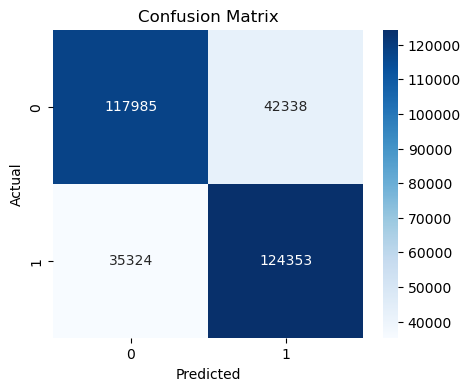


Classification report:

              precision    recall  f1-score   support

    Negative       0.77      0.74      0.75    160323
    Positive       0.75      0.78      0.76    159677

    accuracy                           0.76    320000
   macro avg       0.76      0.76      0.76    320000
weighted avg       0.76      0.76      0.76    320000



In [62]:
# Predict probabilities and labels
y_prob = model.predict(x_test, batch_size=BATCH_SIZE)
y_pred = (y_prob >= 0.5).astype("int32").ravel()

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

## 13.5 Error Analysis

In [65]:
# Error Analysis: Correct vs Incorrect Examples

# Make a copy so we don't overwrite the original
test_df_eval = test_df.copy()
test_df_eval["true_label"] = y_test
test_df_eval["pred_label"] = y_pred

correct_examples = test_df_eval[test_df_eval["true_label"] == test_df_eval["pred_label"]].head(3)
incorrect_examples = test_df_eval[test_df_eval["true_label"] != test_df_eval["pred_label"]].head(3)

print("Correctly classified examples:\n")
display(correct_examples[["text", "clean_text", "true_label", "pred_label"]])

print("\nMisclassified examples:\n")
display(incorrect_examples[["text", "clean_text", "true_label", "pred_label"]])

Correctly classified examples:



,text,clean_text,true_label,pred_label
473,&quot;On popular music&quot; by T.W.Adorno is ...,quot popular music quot w adorno probably diff...,0,0
930692,Ahhh all righty im fine,ahhh righty im fine,1,1
1183094,@alexakesson waaaay ahead of you,waaaay ahead,1,1



Misclassified examples:



,text,clean_text,true_label,pred_label
106190,Can...not...walk....,walk,0,1
299006,arggh just walked through a web,arggh walked web,0,1
876803,it's supposed to be hot today... but it's stil...,supposed hot today still lovely chilly cloudy ...,1,0


# 14. Save Final Model & Tokenizer

In [68]:
# Save Final Model & Tokenizer

model.save("saved_models/rnn_final_model.h5")

import pickle
with open("saved_models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Saved: saved_models/rnn_final_model.h5")
print("Saved: saved_models/tokenizer.pkl")

Saved: saved_models/rnn_final_model.h5
Saved: saved_models/tokenizer.pkl


# 15. Load Model & Real-Time Prediction

In [77]:
# Load Saved Model & Define Real-Time Prediction Function

loaded_model = tf.keras.models.load_model("saved_models/rnn_final_model.h5")

import pickle
with open("saved_models/tokenizer.pkl", "rb") as f:
    loaded_tokenizer = pickle.load(f)

def predict_sentiment(text: str):
    """Return predicted label and probability for a raw text."""
    cleaned = preprocess(text)
    seq = loaded_tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=MAX_SEQ_LENGTH)
    prob = loaded_model.predict(pad)[0][0]
    label = "Positive" if prob >= 0.5 else "Negative"
    return label, float(prob)

## Positive Predictions

In [79]:
predict_sentiment("I love this movie so much! It is amazing!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


('Positive', 0.968345046043396)

## Negative Predictions

In [81]:
predict_sentiment("The weather is okay, not good, not bad.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


('Negative', 0.3149442672729492)

In [87]:
predict_sentiment("I did not like this movie because it's horrible!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


('Negative', 0.20971211791038513)